In [3]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv('./xschem/simulation/example2.txt', sep='\\s+')
df


,frequency,vod_mag
0,1.000000e+03,4.022000
1,1.023000e+03,4.022000
2,1.047000e+03,4.022000
3,1.072000e+03,4.022000
4,1.096000e+03,4.022000
...,...,...
696,9.120000e+09,0.008240
697,9.333000e+09,0.007909
698,9.550000e+09,0.007591
699,9.772000e+09,0.007288


In [ ]:

fig, (ax1, ax2) = plt.subplots(2)
ax1.plot(df1['time'], df1['out'])
ax1.plot(df2['time'], df2['out'], "o")
ax1.grid()
ax1.set_ylabel("out")

ax2.plot(df1['time'], df1['out'])
ax2.plot(df2['time'], df2['out'], "o")
ax2.grid()
ax2.set_xlabel("time")
ax2.set_ylabel("out")
ax2.set_xlim([0, 0.3e-6])
ax2.set_ylim([0.35, 0.55]);

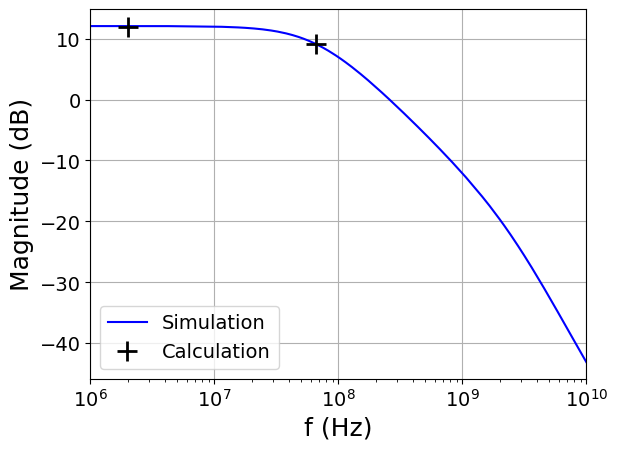

In [ ]:
# Check periodicity/steady state by comparing the last sample of the FFT window with one right before the window
nfft=64
y = df2['out'].values
# Remove last point since it's off the sampling grid
y = y[:-1]
print(len(y))
relative_error = (y[-1]-y[-1-nfft])/y[-1]
print(relative_error)
y = y[-nfft:]
print(len(y))

In [ ]:

spec = np.fft.rfft(y)
spec_dbv = 20*np.log10(np.abs(spec)/(nfft/2))
print(spec_dbv)
     

In [ ]:

plt.plot(spec_dbv, "-o")
plt.grid()
plt.xlabel("Bin number")
plt.ylabel("Magnitude (dBV)");
plt.ylim([-100, 0]);

In [ ]:
hd3_db = spec_dbv[3]-spec_dbv[6]
print(hd3_db)